In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import *
from constants import *

## AnomalyMatch-JWST Analysis Notebook

Exploratory notebook for JWST catalogue matching, lens inspection, manual replacements, and summary statistics. The first cells load the local `DATA/` products (downloaded with `./fetch_esac_data.sh`).

In [2]:
dl_jwst_footprints = pd.read_parquet('DATA/jwst_stage3_footprints.parquet')

astrodeep_cat = pd.read_csv("DATA/ASTRODEEP_cat.csv")
astrodeep_matches_df = pd.read_parquet('DATA/astrodeep_footprint_matches.parquet')
astrodeep_photoz_df = pd.read_csv('DATA/all_ASTRODEEP_photoz_df.csv')

cosmos_web_cat_df = pd.read_csv('DATA/COSMOS_cat.csv')
cosmos_matches_df = pd.read_parquet('DATA/cosmos_footprint_matches.parquet')
cosmos_photoz_df = pd.read_csv('DATA/all_COSMOS_photoz_df.csv')

all_cutouts_df = pd.read_parquet('DATA/all_cutouts_df.parquet')
astrodeep_cutouts_df = all_cutouts_df[all_cutouts_df['CATALOGUE'] == 'astrodeep']
cosmos_cutouts_df = all_cutouts_df[all_cutouts_df['CATALOGUE'] == 'cosmos']

confirmed_lenses_df = pd.read_csv('DATA/lenses_confirmed.csv')

In [3]:
astrodeep_matches_df

,RA,DEC,ID,seg_area,file_path
20155,3.555657,-30.407377,ABELL2744_9233,76.0,/media/home/data/user/jwst_jw02/jw02561/jw0256...
21001,3.559352,-30.407708,ABELL2744_8845,1866.0,/media/home/data/user/jwst_jw02/jw02561/jw0256...
21541,3.561666,-30.407647,ABELL2744_8724,1819.0,/media/home/data/user/jwst_jw02/jw02561/jw0256...
21336,3.560804,-30.407598,ABELL2744_9119,553.0,/media/home/data/user/jwst_jw02/jw02561/jw0256...
20801,3.558494,-30.407353,ABELL2744_9274,24.0,/media/home/data/user/jwst_jw02/jw02561/jw0256...
...,...,...,...,...,...
530555,215.158364,52.972712,CEERS_7547,29.0,/media/home/data/user/jwst_jw06/jw06368/jw0636...
530378,215.155126,52.973337,CEERS_9297,29.0,/media/home/data/user/jwst_jw06/jw06368/jw0636...
530400,215.155339,52.973673,CEERS_9196,148.0,/media/home/data/user/jwst_jw06/jw06368/jw0636...
530304,215.154092,52.973800,CEERS_9969,41.0,/media/home/data/user/jwst_jw06/jw06368/jw0636...


In [4]:
print(f"Summary:\n")

print("Sources in Catalogues:")
print(f"- {len(astrodeep_cat):,} sources in the ASTRODEEP catalogue.")
print(f"- {len(cosmos_web_cat_df):,} sources in the COSMOS catalogue.")
print(f"- Total sources:{len(astrodeep_cat) + len(cosmos_web_cat_df):,}.\n")
print("Sources Matches and Cutouts:")
print(f"- {len(astrodeep_cutouts_df):,} sources with cutouts in the ASTRODEEP footprints.")
print(f"- {len(cosmos_cutouts_df):,} sources with cutouts in the COSMOS footprints.")
print(f"- Total matches: {len(astrodeep_matches_df) + len(cosmos_matches_df):,}.")
print(f"- Total cutouts (after filtering): {len(astrodeep_cutouts_df) + len(cosmos_cutouts_df):,}.")


Summary:

Sources in Catalogues:
- 531,173 sources in the ASTRODEEP catalogue.
- 399,980 sources in the COSMOS catalogue.
- Total sources:931,153.

Sources Matches and Cutouts:
- 314,449 sources with cutouts in the ASTRODEEP footprints.
- 299,566 sources with cutouts in the COSMOS footprints.
- Total matches: 865,922.
- Total cutouts (after filtering): 614,015.


In [5]:
print(f"There are {len(astrodeep_cutouts_df):,} ASTRODEEP cutouts in the combined cutout table.")
print(f"There are {len(cosmos_cutouts_df):,} COSMOS cutouts in the combined cutout table.")
print(f"The full cutout table contains {len(astrodeep_cutouts_df) + len(cosmos_cutouts_df):,} rows.")

There are 314,449 ASTRODEEP cutouts in the combined cutout table.
There are 299,566 COSMOS cutouts in the combined cutout table.
The full cutout table contains 614,015 rows.


In [6]:
confirmed_lenses_df

,filename,label,filename_before,file_path,RA,DEC,CATALOGUE,zspec,zphot,Identified,ID,voted_class,zlens,our_ID
0,astrodeep_jw01176-o221_t010_nircam_clear-3.557...,anomaly,astrodeep_jw01176-o221_t010_nircam_clear-3.557...,/media/home/team_workspaces/AnomalyMatch-JWST-...,3.557337,-30.340738,astrodeep,NaN,0.250,False,ABELL2744_31112,Class B.,0.2500,J000003.557-00030.341
1,astrodeep_jw02561-o001_t003_nircam_clear-3.596...,anomaly,astrodeep_jw02561-o001_t003_nircam_clear-3.596...,/media/home/team_workspaces/AnomalyMatch-JWST-...,3.596040,-30.352626,astrodeep,0.2540,0.254,False,ABELL2744_25433,Class A.,0.2540,J000003.596-00030.353
2,MANUAL_jw02561-o001_t003_nircam_clear-3.536550...,anomaly,astrodeep_jw02561-o001_t003_nircam_clear-3.536...,/media/home/team_workspaces/AnomalyMatch-JWST-...,3.536551,-30.361421,astrodeep,NaN,0.700,False,NaN,Class B.,0.7000,J000003.537-00030.361
3,astrodeep_jw02561-o003_t006_nircam_clear-3.620...,anomaly,astrodeep_jw02561-o003_t006_nircam_clear-3.620...,/media/home/team_workspaces/AnomalyMatch-JWST-...,3.620714,-30.369540,astrodeep,NaN,0.275,False,ABELL2744_19792,Class B.,0.2750,J000003.621-00030.370
4,astrodeep_jw01181-c1009_t008_nircam_clear-189....,anomaly,astrodeep_jw01181-c1009_t008_nircam_clear-189....,/media/home/team_workspaces/AnomalyMatch-JWST-...,189.236016,62.205592,astrodeep,0.9540,0.954,True,JADES-GN_19566,Class B.,0.9540,J000189.236+00062.206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,COWLS-jwst-17-23.png,anomaly,COWLS-jwst-17-23.png,/media/home/team_workspaces/AnomalyMatch-JWST-...,150.198584,1.839785,COWLS,0.8932,NaN,True,COSJ100047+015023,Class A.,0.8932,J000150.199+00001.840
65,COWLS-jwst-17-6.png,anomaly,COWLS-jwst-17-6.png,/media/home/team_workspaces/AnomalyMatch-JWST-...,149.974678,2.555446,COWLS,0.7310,NaN,True,COSJ095953+023319,Class A.,0.7310,J000149.975+00002.555
66,COWLS-jwst-17-2.png,anomaly,COWLS-jwst-17-2.png,/media/home/team_workspaces/AnomalyMatch-JWST-...,149.821462,1.906873,COWLS,NaN,1.252,True,COSJ095917+015424,Class A.,1.2520,J000149.821+00001.907
67,COWLS-jwst-17-19.png,anomaly,COWLS-jwst-17-19.png,/media/home/team_workspaces/AnomalyMatch-JWST-...,150.119067,2.324503,COWLS,0.6040,NaN,True,COSJ100028+021928,Class A.,0.6040,J000150.119+00002.325


In [7]:
print(
    f"The maximum spectroscopic redshift with COWLS lenses is "
    f"{confirmed_lenses_df.loc[confirmed_lenses_df['zspec'].notna(), 'zspec'].max():.3f}."
)

print(
    f"The maximum photometric redshift with COWLS lenses is "
    f"{confirmed_lenses_df.loc[confirmed_lenses_df['zphot'].notna(), 'zphot'].max():.3f}."
)

The maximum spectroscopic redshift with COWLS lenses is 1.530.
The maximum photometric redshift with COWLS lenses is 2.449.


In [8]:
print(
    f"The maximum spectroscopic redshift excluding COWLS lenses is "
    f"{confirmed_lenses_df.loc[confirmed_lenses_df['zspec'].notna() & (confirmed_lenses_df['CATALOGUE'] != 'COWLS'), 'zspec'].max():.3f}."
)

print(
    f"The maximum photometric redshift excluding COWLS lenses is "
    f"{confirmed_lenses_df.loc[confirmed_lenses_df['zphot'].notna() & (confirmed_lenses_df['CATALOGUE'] != 'COWLS'), 'zphot'].max():.3f}."
)

The maximum spectroscopic redshift excluding COWLS lenses is 1.390.
The maximum photometric redshift excluding COWLS lenses is 2.100.


In [9]:
astrodeep_cutouts_df.info(), cosmos_cutouts_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 314449 entries, 0 to 314448
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   file_path  314449 non-null  object 
 1   RA         314449 non-null  float64
 2   DEC        314449 non-null  float64
 3   CATALOGUE  314449 non-null  object 
 4   zphot      314449 non-null  float64
 5   flag       314449 non-null  float64
dtypes: float64(4), object(2)
memory usage: 16.8+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 299566 entries, 0 to 299565
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   file_path  299566 non-null  object 
 1   RA         299566 non-null  float64
 2   DEC        299566 non-null  float64
 3   CATALOGUE  299566 non-null  object 
 4   zphot      0 non-null       float64
 5   flag       0 non-null       float64
dtypes: float64(4), object(2)
memory usage: 16.0+ MB


(None, None)

In [10]:
confirmed_lenses_df['ztype'] = ['zspec' if row['zlens'] == row['zspec'] else 'zphot' for idx, row in confirmed_lenses_df.iterrows()]

In [11]:
confirmed_lenses_df[confirmed_lenses_df['filename'].str.startswith('COWLS')==False].sort_values(by=['RA'])[['ID', 'our_ID', 'RA', 'DEC', 'zlens', 'voted_class', 'CATALOGUE', 'Identified', 'ztype']].to_csv('latex_table.csv', index=False)

In [36]:
import pandas as pd

df = pd.read_csv("latex_table.csv")

df["Grade"] = df["voted_class"].str.replace("Class ", "", regex=False).str.replace(".", "", regex=False)
df["Catalogue"] = df["CATALOGUE"].str.upper()
df["ID"] = df["ID"].fillna("--")
grade_order = {"A": 0, "B": 1, "C": 2}
df["grade_sort"] = df["Grade"].map(grade_order)

df_sorted = (
    df
    .sort_values(
        by=["grade_sort", "Identified", "zlens"],
        ascending=[True, True, False]  # A first, False first, high z first
    )
    .drop(columns="grade_sort")
)

# Optional: reset index
df_sorted = df_sorted.reset_index(drop=True)

latex_table = df_sorted.to_latex(
    index=False,
    columns=["ID", "RA", "DEC", "Identified", "zlens", "ztype", "Grade", "Catalogue"],
    header=["ID", "RA", "DEC", "Identified", "$z_lens$", "$z_type$", "Catalogue"],
    caption="Confirmed and candidate lensing systems with positions, redshifts, and classifications.",
    label="tab:lenses",
    longtable=False,
    escape=False
)

print(latex_table)

\begin{table}
\caption{Confirmed and candidate lensing systems with positions, redshifts, and classifications.}
\label{tab:lenses}
\begin{tabular}{lrrrrlll}
\toprule
ID & RA & DEC & Grade & Identified & $z_lens$ & $z_type$ & Catalogue \\
\midrule
-- & 149.794040 & 2.008240 & 1.414000 & False & zphot & A & COSMOS \\
CEERS_56193 & 214.888879 & 52.883553 & 1.060000 & False & zspec & A & ASTRODEEP \\
JADES-GS_14262 & 53.100356 & -27.870796 & 1.013000 & False & zspec & A & ASTRODEEP \\
PRIMER-COSMOS_8436 & 150.092521 & 2.202988 & 0.674000 & False & zspec & A & ASTRODEEP \\
PRIMER-UDS_50243 & 34.275995 & -5.221575 & 0.628000 & False & zspec & A & ASTRODEEP \\
PRIMER-UDS_753 & 34.340047 & -5.316749 & 0.625000 & False & zphot & A & ASTRODEEP \\
ABELL2744_15500 & 3.554197 & -30.376287 & 0.309000 & False & zspec & A & ASTRODEEP \\
ABELL2744_25433 & 3.596040 & -30.352626 & 0.254000 & False & zspec & A & ASTRODEEP \\
ABELL2744_21147 & 3.578037 & -30.359454 & 0.200000 & False & zphot & A & ASTRODEE

In [33]:
len(df[df['voted_class']=='Class A.']), len(df)

(16, 58)

In [62]:
nonreferenced_df = df[df['Identified']==False]
len(nonreferenced_df[nonreferenced_df['voted_class']=='Class A.']),  len(nonreferenced_df[nonreferenced_df['voted_class']=='Class B.']),  len(nonreferenced_df[nonreferenced_df['voted_class']=='Class C.'])

(9, 10, 18)

In [64]:
nonreferenced_df[nonreferenced_df['zlens']==2.1]

,ID,our_ID,RA,DEC,zlens,voted_class,CATALOGUE,Identified,ztype
31,NaN,J000053.120-00027.842,53.119966,-27.842394,2.1,Class C.,astrodeep,False,zphot


### Manual ID generation

In [19]:
import pandas as pd

def format_id(ra, dec):
    sign = "+" if dec >= 0 else "-"
    return f"J{ra:010.3f}{sign}{abs(dec):09.3f}"

confirmed_lenses_df["our_ID"] = confirmed_lenses_df.apply(
    lambda row: format_id(row["RA"], row["DEC"]), axis=1
)

In [21]:
confirmed_lenses_df['RA'] = confirmed_lenses_df['RA'].round(6)
confirmed_lenses_df['DEC'] = confirmed_lenses_df['DEC'].round(6)

confirmed_lenses_df['arc_tag'] = np.full(len(confirmed_lenses_df), None)

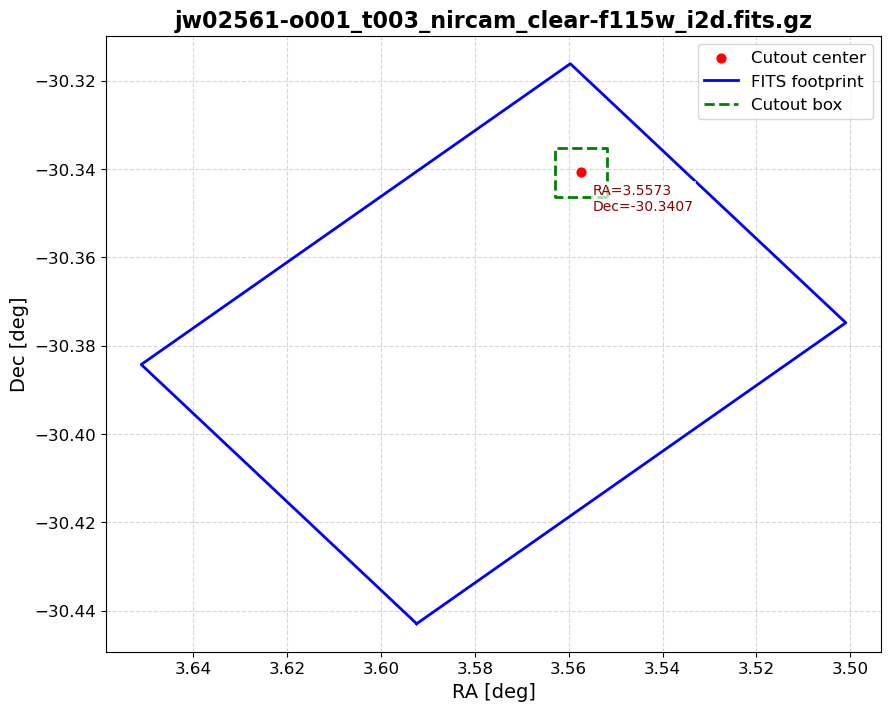

In [38]:
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np

def plot_fits_footprints_temp(
    i, 
    fits_paths, 
    ras, 
    decs, 
    size_arcsec=10, 
    title="JWST FITS Footprints"
):
    fig, ax = plt.subplots(figsize=(10, 8))

    ax.scatter(ras, decs, color='red', s=40, label='Cutout center', zorder=3)

    for ra, dec in zip(ras, decs):
        ax.text(
            ra - 0.0025, dec - 0.0025,  # small offset in deg (~1 arcsec)
            f"RA={ra:.4f}\nDec={dec:.4f}",
            fontsize=10, ha="left", va="top", color="darkred",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5)
        )

    for fits_path in fits_paths:
        with fits.open(fits_path) as hdul:
            wcs = WCS(hdul['SCI'].header)
            footprint = wcs.calc_footprint()
            footprint = np.vstack([footprint, footprint[0]])  # close polygon
            ax.plot(
                footprint[:, 0], footprint[:, 1],
                color='blue', lw=2, label='FITS footprint'
            )

    size_deg = size_arcsec / 3600.0
    half_size = size_deg / 2.0

    for ra, dec in zip(ras, decs):
        square_ra = [ra - half_size, ra + half_size, ra + half_size, ra - half_size, ra - half_size]
        square_dec = [dec - half_size, dec - half_size, dec + half_size, dec + half_size, dec - half_size]
        ax.plot(
            square_ra, square_dec,
            color='green', linestyle='--', lw=2, label='Cutout box'
        )

    ax.set_xlabel("RA [deg]", fontsize=14)
    ax.set_ylabel("Dec [deg]", fontsize=14)
    ax.set_title(title, fontsize=16, weight="bold")

    ax.tick_params(axis="both", labelsize=12)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), fontsize=12)

    plt.grid(True, linestyle="--", alpha=0.5)
    plt.gca().invert_xaxis()

    plt.savefig(f"{i}.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

plot_fits_footprints_temp(0, 
                          [astrodeep_matches_df.iloc[0]['file_path']], 
                          [confirmed_lenses_df['RA'].iloc[0]], 
                          [confirmed_lenses_df['DEC'].iloc[0]], 
                          size_arcsec=40, 
                          title=astrodeep_matches_df.iloc[0]['file_path'].split('/')[-1])

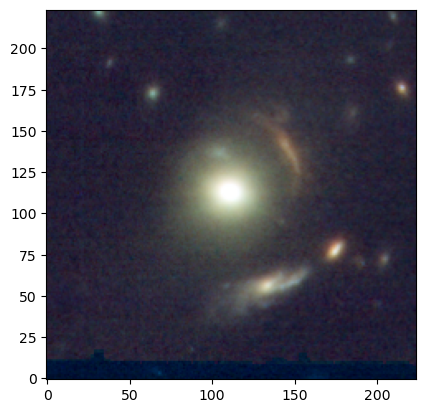

In [102]:
import cv2

base_pth = '/media/home/data/user/jwst_jw01/jw01837/' 
obs = 'jw01837-c1002_t001_nircam_clear-'
files = [base_pth+obs+'f115w'+'_i2d.fits.gz',
         base_pth+obs+'f150w'+'_i2d.fits.gz',
         base_pth+obs+'f277w'+'_i2d.fits.gz',
         base_pth+obs+'f444w'+'_i2d.fits.gz']

ra, dec = 34.340047, -5.316749

res = combined_rgb_cutout(files, ra, dec, f'./cutout_{obs}-{ra}-{dec}.png', size_arcsec=10, orient_cutout=True)
path_to_save = '/media/home/team_workspaces/AnomalyMatch-JWST-Lenses/dataset_v2/manual_replace_files/MANUAL_' + obs + f"{ra}-{dec}.png"

# print(path_to_save)
# print(files[0])
# cv2.imwrite(path_to_save, cv2.cvtColor(res[0], cv2.COLOR_RGB2BGR))

## Cross-reference for lens identification

In [42]:
from astroquery.esasky import ESASky
from astropy.coordinates import SkyCoord
import astropy.units as u
import requests
from astropy.io.votable import parse_single_table
import io

token = '... (ADS token)'

def query_ads_publications(ra, dec, token, radius_arcsec):
    radius_deg = radius_arcsec / 3600
    radius_str = f"{radius_deg:.8f}"
    url = f"https://adsabs.harvard.edu/cgi-bin/abs_connect?data_type=VOTABLE&RA={ra}&DEC={dec}&SR={radius_deg}"

    r = requests.get(url)
    votable = parse_single_table(io.BytesIO(r.content))
    table = votable.to_table()

    return table

def query_esasky_for_lens(ra, dec, radius, token=token):
    """
    Query ESASky around a coordinate and check for lens-related references.
    """
    coord = SkyCoord(ra, dec, unit="deg")
    results = ESASky.query_region_catalogs(coord, radius=radius*u.arcsec, catalogs="all")
    pub_results = query_ads_publications(ra, dec, token, radius_arcsec=radius)
    lens_keywords = ["lens", "lensed", "gravlens", "strong lens", "lensing"]
    lens_flag= False
    if len(pub_results) > 0:
        for row in pub_results:
            title = str(row.get("title", "")).lower()
            summary = str(row.get("abstract", "")).lower() if "abstract" in row.colnames else ""
            if any(kw in title or kw in summary for kw in lens_keywords):
                lens_flag = True
                print(f"ADS publication mentions lensing: {row['bibcode']} — {row['title']}")
        
    if not results or len(results) == 0:
        return {"lens_flag": False, "matches": [], 'ra': ra, 'dec': dec}

    matches = []
    lens_keywords = ["lens", "lensed", "gravlens", "strong lens", "lensing"]

    for i, table in enumerate(results):
        cat_name = results.keys()[i]  
        for row in table:
            print('Match ID', row.get("target_name", "None"), row.get("match_id", "None"))
            print(row.columns)
            obj_info = {
                "catalog": cat_name,
                "name": row.get("MAIN_ID", row.get("Name", "unknown")),
                "otype": row.get("OTYPE", row.get("type", "unknown")),
                "description": row.get("OTYPE_LONG", row.get("description", "")),
                "ra": ra,
                "dec": dec,
                "tab_ra": row["ra"] if "ra" in row.colnames else None,
                "stab_dec": row["dec"] if "dec" in row.colnames else None
            }

            text_fields = " ".join([
                str(obj_info.get("otype", "")),
                str(obj_info.get("description", ""))
            ]).lower()
            if any(kw in text_fields for kw in lens_keywords):
                lens_flag = True
                
            for zcol in ["z", "z_spec", "zphot", "zspec", "redshift"]:
                if zcol in row.colnames:
                    obj_info[zcol] = row[zcol]
            matches.append(obj_info)

    return {"lens_flag": lens_flag, "matches": matches}

## Mosaic plot of lenses

In [25]:
# Assigning arc label to a source

ra = 3.579403
print(confirmed_lenses_df[confirmed_lenses_df['RA'] == ra]['arc_tag'])
confirmed_lenses_df.loc[confirmed_lenses_df['RA'] == ra, 'arc_tag'] = 'arc'
len(confirmed_lenses_df[confirmed_lenses_df['arc_tag'].isna() == False][confirmed_lenses_df['arc_tag'] == 'arc'])

8    None
Name: arc_tag, dtype: object


/tmp/ipykernel_333/1933638273.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  len(confirmed_lenses_df[confirmed_lenses_df['arc_tag'].isna() == False][confirmed_lenses_df['arc_tag'] == 'arc'])


1

In [19]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import numpy as np
import os
import cv2
from math import ceil
import matplotlib.patches as patches

def plot_mosaic(df, output_path, grid_size=(9, 7), tag_col=None):
    n_rows, n_cols = grid_size
    n_imgs = n_rows * n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))
    plt.subplots_adjust(wspace=0, hspace=0, left=0, right=1, top=1, bottom=0)
    axes = axes.flatten()
    
    for ax in axes:
        ax.axis("off")
    
    for i, (_, row) in enumerate(df.head(n_imgs).iterrows()):
        file_path = '/media/home/my_workspace/AnomalyMatch/cutouts_dir/' + row['filename'] if row['filename'].startswith('MANUAL') else row['file_path']
        
        if not os.path.exists(file_path):
            print('not there', file_path)
            continue
        
        img = np.array(Image.open(file_path))
        ax = axes[i]
        ax.imshow(img)

        if tag_col and pd.notna(row.get(tag_col)):
            tag_text = str(row[tag_col])
            
            triangle = patches.Polygon(
                [[0.85, 1], [1, 1], [1, 0.85]], 
                closed=True, 
                transform=ax.transAxes,
                color="red", alpha=0.6
            )
            ax.add_patch(triangle)
            
            ax.text(0.925, 0.96, tag_text[:3], 
                    transform=ax.transAxes, 
                    fontsize=5, color="white", 
                    ha="center", va="center", weight="bold")

        ra = f"{row['RA']:.6f}" if pd.notna(row.get("RA")) else "NA"
        dec = f"{row['DEC']:.6f}" if pd.notna(row.get("DEC")) else "NA"
        zphot = f"zphot={row['zphot']:.2f}" if pd.notna(row.get("zphot")) and row["zphot"] > -10 and (row.get("zspec") == -99.0 or math.isnan(row.get("zspec"))) else ""
        zspec = f"zspec={row['zspec']:.2f}" if pd.notna(row.get("zspec")) and row["zspec"] > -10 else ""
        arc_tag = f"Lensed arc" if pd.notna(row.get("arc_tag")) else ""
        
        ax.text(0.02, 0.95, f"{ra}, {dec}",
                transform=ax.transAxes,
                fontsize=7, color="white",
                ha="left", va="top")
        
        extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
        
        if zspec:
            ax.text(0.02, 0.85, zspec,
                    transform=ax.transAxes,
                    fontsize=7, color="cyan",
                    ha="left", va="top")

        if zphot:
            ax.text(0.02, 0.85, zphot,
                    transform=ax.transAxes,
                    fontsize=7, color="yellow",
                    ha="left", va="top")
        if arc_tag:
            ax.text(0.99, 0.02, arc_tag,
                    transform=ax.transAxes,
                    fontsize=7, color="white",
                    ha="right", va="bottom")
    
    plt.savefig(output_path, dpi=300, bbox_inches="tight", pad_inches=0)
    plt.close(fig)

# Case 1: Class A
df_A = confirmed_lenses_df[confirmed_lenses_df['voted_class'] == 'Class A.'][confirmed_lenses_df['filename'].str.startswith('COWLS') == False]
df_A = df_A.sort_values(by=['RA', 'DEC'], ascending=True)
plot_mosaic(df_A, "./mosaic_A.pdf", grid_size=(4,4))

# Case 2: Class B
df_B = confirmed_lenses_df[confirmed_lenses_df['voted_class'] == 'Class B.'][confirmed_lenses_df['filename'].str.startswith('COWLS') == False]
df_B = df_B.sort_values(by=['RA', 'DEC'], ascending=True)

# Case 3: Class C
df_C = confirmed_lenses_df[confirmed_lenses_df['voted_class'] == 'Class C.'][confirmed_lenses_df['filename'].str.startswith('COWLS') == False]
df_C = df_C.sort_values(by=['RA', 'DEC'], ascending=True)

plot_mosaic(df_B, "mosaic_B.pdf", grid_size=(4, 4))
plot_mosaic(df_C[:20], "mosaic_C_part1.pdf", grid_size=(5, 2))
plot_mosaic(df_C[20:], "mosaic_C_part2.pdf", grid_size=(4,4))

# # Case 4: COWLS catalogue
df_COWLS = confirmed_lenses_df[confirmed_lenses_df['filename'].str.startswith('COWLS')] # !!! make distinction between COWLS imgs used initially or found in dataset
df_COWLS = df_COWLS.sort_values(by=['RA', 'DEC'], ascending=True)
plot_mosaic(df_COWLS, "./mosaic_COWLS.pdf", grid_size=(4,3))

/var/folders/yt/bb0b3qn56ksc7bnrm32571qm0000gn/T/ipykernel_77241/3721141369.py:82: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_A = confirmed_lenses_df[confirmed_lenses_df['voted_class'] == 'Class A.'][confirmed_lenses_df['filename'].str.startswith('COWLS') == False]
/var/folders/yt/bb0b3qn56ksc7bnrm32571qm0000gn/T/ipykernel_77241/3721141369.py:87: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_B = confirmed_lenses_df[confirmed_lenses_df['voted_class'] == 'Class B.'][confirmed_lenses_df['filename'].str.startswith('COWLS') == False]
/var/folders/yt/bb0b3qn56ksc7bnrm32571qm0000gn/T/ipykernel_77241/3721141369.py:91: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_C = confirmed_lenses_df[confirmed_lenses_df['voted_class'] == 'Class C.'][confirmed_lenses_df['filename'].str.startswith('COWLS') == False]


not there /media/home/team_workspaces/AnomalyMatch-JWST-Lenses/DATA/dataset_v2/training_images/astrodeep_jw01176-o221_t010_nircam_clear-3.554197--30.376287.png
not there /media/home/team_workspaces/AnomalyMatch-JWST-Lenses/DATA/dataset_v2/training_images/astrodeep_jw02561-o003_t006_nircam_clear-3.578037--30.359454.png
not there /media/home/team_workspaces/AnomalyMatch-JWST-Lenses/DATA/dataset_v2/training_images/astrodeep_jw02561-o001_t003_nircam_clear-3.59604--30.352626.png
not there /media/home/team_workspaces/AnomalyMatch-JWST-Lenses/DATA/dataset_v2/training_images/astrodeep_jw02756-o003_t001_nircam_clear-3.609545--30.382099.png
not there /media/home/team_workspaces/AnomalyMatch-JWST-Lenses/DATA/dataset_v2/training_images/astrodeep_jw01837-o009_t011_nircam_clear-34.275995--5.221575.png
not there /media/home/team_workspaces/AnomalyMatch-JWST-Lenses/DATA/dataset_v2/training_images/astrodeep_jw01837-c1002_t001_nircam_clear-34.340047--5.316749.png
not there /media/home/team_workspaces/An

In [92]:
len(confirmed_lenses_df), len(df_A), len(df_B), len(df_C), len(df_A) + len(df_B) + len(df_C)

(69, 16, 16, 26, 58)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D
import astropy.units as u

def minmax_norm(img):
    return (img - np.nanmin(img)) / (np.nanmax(img) - np.nanmin(img))

def zscale_norm(img, low=0.5, high=99.5):
    vmin, vmax = np.percentile(img[np.isfinite(img)], [low, high])
    return np.clip((img - vmin) / (vmax - vmin), 0, 1)

def asinh_norm(img, scale=None):
    if scale is None:
        scale = np.median(img[np.isfinite(img)])
    return np.arcsinh(img / scale) / np.arcsinh(np.nanmax(img) / scale)

def mtf_norm(img, desired_mean_normalized=0.25):
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    valid = img > 0
    img = np.clip(img, img.min(), np.percentile(img, 99.5))
    norm = np.zeros_like(img, dtype=np.float64)
    norm[valid] = (img[valid] - img[valid].min()) / (img[valid].max() - img[valid].min())
    x = np.mean(norm[valid])
    alpha = desired_mean_normalized
    m = (x - alpha*x) / (x - 2*alpha*x + alpha)
    y = np.zeros_like(norm)
    mask0, maskm, mask1 = (norm==0), (norm==m), (norm==1)
    mask_else = ~(mask0|maskm|mask1)
    y[mask0], y[maskm], y[mask1] = 0, 0.5, 1
    xe = norm[mask_else]
    y[mask_else] = ((m-1)*xe)/((2*m-1)*xe - m)
    return y

def make_cutout(fits_file, ra, dec, size_arcsec):
    with fits.open(fits_file) as hdul:
        w = WCS(hdul[1].header)
        data = hdul[1].data
    coord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
    cutout = Cutout2D(data, coord, size_arcsec*u.arcsec, wcs=w)
    return cutout.data

def plot_cutout_normalizations(fits_file, ra, dec, size_arcsec=10, title="JWST Cutout Normalizations"):
    cutout = make_cutout(fits_file, ra, dec, size_arcsec=size_arcsec)

    # Apply normalizations
    norms = {
        "Min-Max": minmax_norm(cutout),
        "ZScale": zscale_norm(cutout),
        "Asinh": asinh_norm(cutout),
        "MTF": mtf_norm(cutout)
    }
    
    for name, img in norms.items():
        plt.imshow(img, cmap="gray", origin="lower") 
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(name+'.png', dpi=200)
        plt.show()
        plt.close()
        
    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    for ax, (name, img) in zip(axes, norms.items()):
        ax.imshow(img, cmap="gray", origin="lower")
        ax.set_title(name, fontsize=14, weight="bold")
        ax.tick_params(axis="both", labelsize=12)
        ax.axis("off")

    # plt.suptitle(title, fontsize=16, weight="bold")
    plt.tight_layout()
    plt.savefig('./cutout_stretch_comparisons.png', dpi=200)
    plt.show()

plot_cutout_normalizations('/some/fits/example.fits', ra, dec, size_arcsec=10, title=files[0].split('/')[-1])

## Confirmed lenses

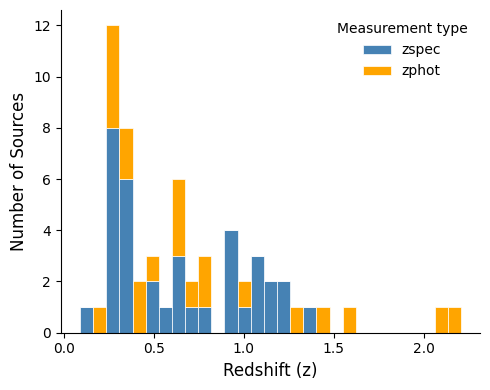

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

labelled_data_non_COWLS = confirmed_lenses_df[confirmed_lenses_df["filename"].str.startswith("COWLS")==False]
bins = np.linspace(
    np.min(labelled_data_non_COWLS["zlens"]),
    np.max(labelled_data_non_COWLS["zlens"]),
    30
)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots(figsize=(5, 4))

colors = {"zspec": 'steelblue', "zphot": 'orange'}
ordered_sources = ["zspec", "zphot"]

data_by_source_zspec = [
    row["zspec"] for idx, row in labelled_data_non_COWLS.iterrows() if math.isnan(row["zspec"]) == False]
data_by_source_zphot = [
    row["zphot"] for idx, row in labelled_data_non_COWLS.iterrows() if math.isnan(row["zphot"]) == False and math.isnan(row["zspec"])]

data_by_source = [data_by_source_zspec, data_by_source_zphot]
hist_colors = [colors[src] for src in ordered_sources]

ax.hist(
    data_by_source,
    bins=bins,
    stacked=True,
    color=hist_colors,
    edgecolor="white",
    linewidth=0.5,
    label=ordered_sources
)

ax.set_xlabel("Redshift (z)", fontsize=12)
ax.set_ylabel("Number of Sources", fontsize=12)
ax.legend(title="Measurement type", frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig("redshifts_hist.pdf", dpi=200)
plt.show()

In [ ]:
!pip install seaborn

/var/folders/yt/bb0b3qn56ksc7bnrm32571qm0000gn/T/ipykernel_77241/729062485.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


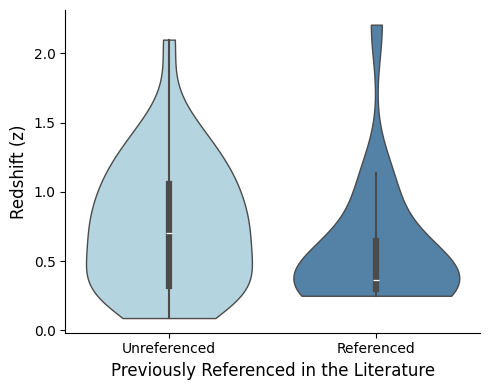

In [18]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

data = confirmed_lenses_df[confirmed_lenses_df["filename"].str.startswith("COWLS")==False].dropna(subset=["zlens", "Identified"]).copy()
data["Identified_label"] = data["Identified"].map({True: "Referenced", False: "Unreferenced"})

fig, ax = plt.subplots(figsize=(5, 4))

palette = {"Referenced": "steelblue", "Unreferenced": "lightblue"}
order = ["Unreferenced", "Referenced"]

sns.violinplot(
    x="Identified_label",
    y="zlens",
    data=data,
    palette=palette,
    order=order,
    inner="box",
    cut=0,
    linewidth=1.0,
    ax=ax
)

ax.set_xlabel("Previously Referenced in the Literature", fontsize=12)
ax.set_ylabel("Redshift (z)", fontsize=12)

plt.tight_layout()
plt.savefig("violin_redshifts_identified.png", dpi=200)
plt.show()

In [103]:
np.median(confirmed_lenses_df.sort_values(by=['RA'])[:21]['zlens']) # Abel 2744 cluster median

0.305

In [82]:
np.mean(confirmed_lenses_df[confirmed_lenses_df['filename'].str.startswith('COWLS')==False]['zlens']), np.median(confirmed_lenses_df[confirmed_lenses_df['filename'].str.startswith('COWLS')==False]['zlens'])

(0.6982827586206898, 0.6265000000000001)

In [87]:
np.min(confirmed_lenses_df[confirmed_lenses_df['filename'].str.startswith('COWLS')==False]['zlens']), np.max(confirmed_lenses_df[confirmed_lenses_df['filename'].str.startswith('COWLS')==False]['zlens'])

(0.089, 2.208)

In [88]:
np.min(confirmed_lenses_df[confirmed_lenses_df['filename'].str.startswith('COWLS')==True]['zlens']), np.max(confirmed_lenses_df[confirmed_lenses_df['filename'].str.startswith('COWLS')==True]['zlens'])

(0.469, 2.449)

In [ ]:
np.mean(confirmed_lenses_df[confirmed_lenses_df['Identified'] == False]['zphot'].dropna().values), np.median(confirmed_lenses_df[confirmed_lenses_df['Identified'] == False]['zphot'].dropna().values)

(0.7705405405405406, 0.7)

In [ ]:
np.mean(confirmed_lenses_df[confirmed_lenses_df['Identified'] == True]['zphot'].dropna().values), np.median(confirmed_lenses_df[confirmed_lenses_df['Identified'] == True]['zphot'].dropna().values)

(0.750912, 0.4719)

## Sky plot of lenses

In [108]:
df1 = pd.merge(all_cutouts_df, astrodeep_matches_df, on=['RA', 'DEC'], how='inner')
df2 = pd.merge(all_cutouts_df, cosmos_matches_df, on=['RA', 'DEC'], how='inner')

cutout_footprints_df = pd.concat([df1, df2], axis=0)

In [203]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import numpy as np

centers = []

for footprint in DL_cutout_footprints['footprint'].dropna():
    footprint = np.array([np.array(fp) for fp in footprint])
    fp_ra, fp_dec = footprint[:,0], footprint[:,1]
    center = SkyCoord(ra=np.mean(fp_ra)*u.deg, dec=np.mean(fp_dec)*u.deg, frame="icrs")
    centers.append(center)

centers = SkyCoord(centers)

# DB-Scan

from sklearn.cluster import DBSCAN

clusterring_radius = 3 # deg
X = np.vstack([centers.ra.radian, centers.dec.radian]).T
eps = (clusterring_radius*u.deg).to(u.rad).value 
labels = DBSCAN(eps=eps, min_samples=1, metric='euclidean').fit_predict(X)

{'jw02561', 'jw01176', 'jw01324', 'jw02756'}
{'jw01180', 'jw04498', 'jw01210', 'jw01176', 'jw06541', 'jw02079', 'jw01286', 'jw02079_backup'}
{'jw01181', 'jw01264'}
{'jw04287', 'jw06368', 'jw02750', 'jw01345'}
{'jw01837', 'jw06585', 'jw01727', 'jw01810'}
{'jw01837'}


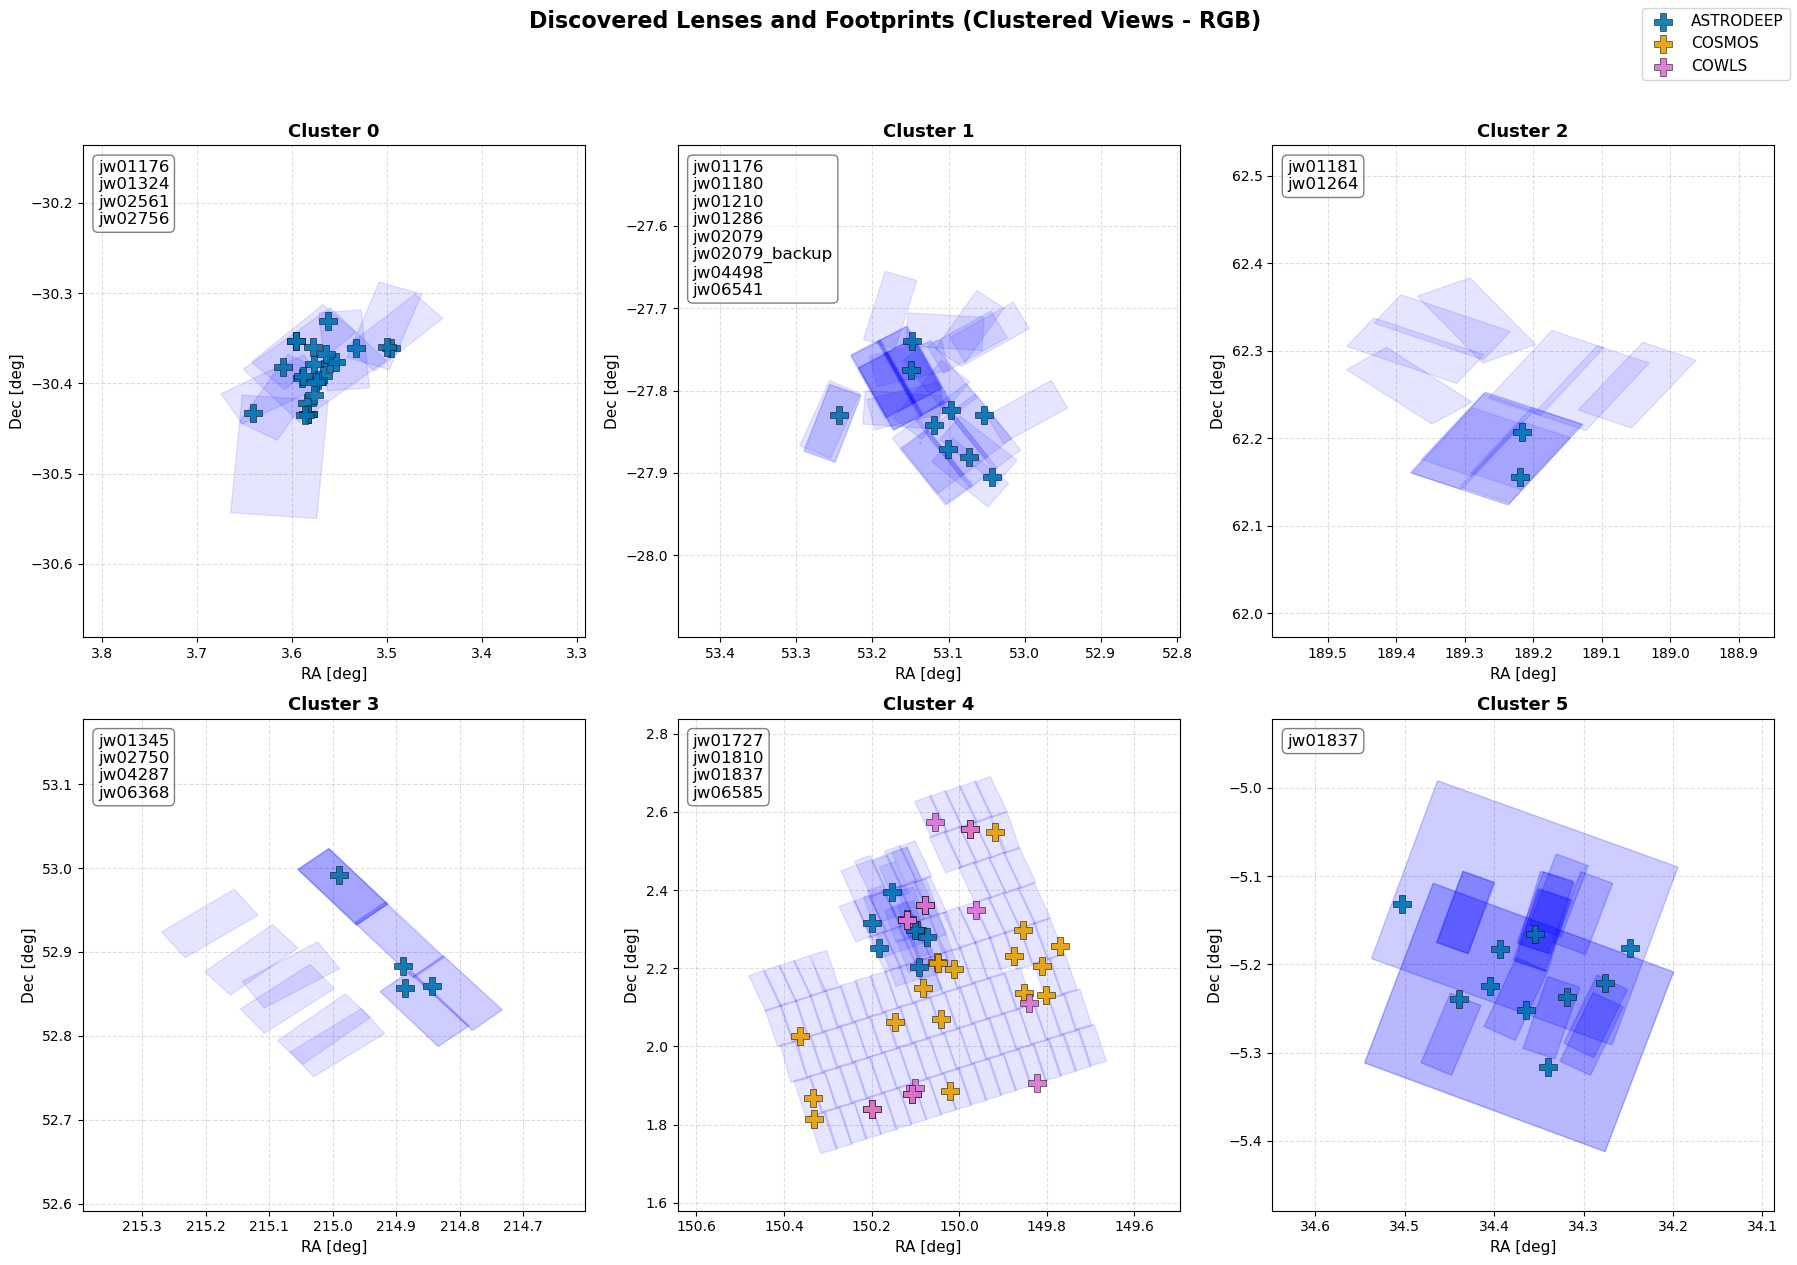

In [302]:
import matplotlib.pyplot as plt
import numpy as np

color_map = {
    "astrodeep": "#0072B2", 
    "cosmos": "#E69F00",    
    "COWLS": "orchid"     
}

window_around_cluster = 0.2
cluster_ids = np.unique(labels)

n_clusters = len(cluster_ids)
ncols = 3
nrows = int(np.ceil(n_clusters / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 6*nrows))
axes = axes.flatten()

for ax, cid in zip(axes, cluster_ids):
    mask = labels == cid
    cluster_centers = centers[mask]

    ra_c = cluster_centers.ra.deg.mean()
    dec_c = cluster_centers.dec.deg.mean()
    min_ra_c = cluster_centers.ra.deg.min()
    min_dec_c = cluster_centers.dec.deg.min()
    max_ra_c = cluster_centers.ra.deg.max()
    max_dec_c = cluster_centers.dec.deg.max()
    obs_codes = set(fp.split('/')[-2] for fp in DL_cutout_footprints['file_path'].dropna()[mask])
    print(obs_codes)
    
    for footprint in DL_cutout_footprints['footprint'].dropna()[mask]:
        footprint = np.array([np.array(fp) for fp in footprint])
        fp_ra, fp_dec = footprint[:, 0], footprint[:, 1]
        ax.fill(fp_ra, fp_dec, facecolor="blue", edgecolor="blue", alpha=0.1, zorder=2)

    for _, row in confirmed_lenses_df.iterrows():
        fpath = row["file_path"]
        ra, dec = row["RA"], row["DEC"]

        color = "gray"
        for key, val in color_map.items():
            if key.lower() in fpath.lower():
                color = val
                break

        ax.scatter(ra, dec,
                   marker="P", s=150,
                   color=color, edgecolor="black", linewidth=0.4, alpha=0.9,
                   zorder=5, label=key)

    ax.set_xlim(min_ra_c - window_around_cluster, max_ra_c + window_around_cluster) 
    ax.set_ylim(min_dec_c - window_around_cluster, max_dec_c + window_around_cluster)

    ax.set_xlabel("RA [deg]", fontsize=11)
    ax.set_ylabel("Dec [deg]", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.invert_xaxis()
    ax.set_title(f"Cluster {cid}", fontsize=13, fontweight="bold")

    obs_text = "\n".join(sorted(obs_codes))
    ax.text(0.03, 0.97, obs_text, transform=ax.transAxes,
            fontsize=12, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.5))

for j in range(len(cluster_ids), len(axes)):
    axes[j].set_visible(False)

handles, labels_ = axes[0].get_legend_handles_labels()
labels_ = [label.upper() for label in labels_]
by_label = dict(zip(labels_, handles))
fig.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=11)

fig.suptitle("Discovered Lenses and Footprints (Clustered Views - RGB)", 
             fontsize=16, fontweight="bold", y=1.05)
fig.tight_layout()
plt.savefig('all_lens_footprints.png', dpi=200)
plt.show()

## Zooniverse class voting

In [85]:
import json

votes_zooniverse = pd.read_csv('DATA/galaxy-lens-class-voting-classifications.csv')
votes_zooniverse['filename'] = np.full(len(votes_zooniverse), None)

for idx, row in votes_zooniverse.iterrows():
    subj_data_dict = json.loads(row['subject_data'])
    filename = next(elem['Filename'] for elem in subj_data_dict.values())
    votes_zooniverse.iloc[idx, votes_zooniverse.columns.get_loc('filename')] = filename.replace('.png.png','.png')

confirmed_lenses_df = pd.read_csv('/media/home/team_workspaces/AnomalyMatch-JWST-Lenses/dataset_v2/other_lens_datasets/confirmed_lenses_df_lenses_only.csv')     
confirmed_lenses_df['voted_class'] = np.full(len(confirmed_lenses_df), None)

for idx, row in confirmed_lenses_df.iterrows():
    print('filename', row['filename'])
    found = 0
    for idx2, row2 in votes_zooniverse[votes_zooniverse['filename'] == row['filename']].iterrows():
        class_dict = {'Class A.': 0, 'Class B.':0, 'Class C.':0, 'Not a lens.':0}
        parsed_annots = json.loads(row2['annotations'])
        for annot in parsed_annots:
            if annot['task_label'] == 'Please classify this lens candidate (coords in the image filename).':
                class_dict[annot['value']] +=1
                found +=1
    if found:
        confirmed_lenses_df.iloc[idx, confirmed_lenses_df.columns.get_loc('voted_class')] = [key for key in class_dict if class_dict[key]==max(class_dict.values())][0]
    else:
        print(row['filename'], 'not found')

filename astrodeep_jw01176-o221_t010_nircam_clear-3.557337--30.340738.png
filename astrodeep_jw02561-o001_t003_nircam_clear-3.59604--30.352626.png
filename MANUAL_jw02561-o001_t003_nircam_clear-3.5365508--30.3614214.png
filename astrodeep_jw02561-o003_t006_nircam_clear-3.620714--30.36954.png
filename astrodeep_jw01176-o221_t010_nircam_clear-3.559228--30.349188.png
filename astrodeep_jw01181-c1009_t008_nircam_clear-189.236016-62.205592.png
filename MANUAL_jw01181-o005_t008_nircam_clear-189.1888352-62.1984922.png
filename astrodeep_jw01181-o005_t008_nircam_clear-189.205931-62.229689.png
filename astrodeep_jw01345-o003_t023_nircam_clear-214.815355-52.87097.png
filename astrodeep_jw01727-o057_t075_nircam_clear-150.169421-2.36265.png
filename astrodeep_jw02561-o001_t003_nircam_clear-3.585307--30.387526.png
filename MANUAL_jw02561-o001_t003_nircam_clear-3.5885824--30.3925159.png
filename astrodeep_jw02561-o001_t003_nircam_clear-3.595497--30.388669.png
filename astrodeep_jw02561-o003_t006_nir

In [86]:
confirmed_lenses_df_confirmed_lenses = confirmed_lenses_df[confirmed_lenses_df['voted_class'] != 'Not a lens.']
confirmed_lenses_df_confirmed_lenses = confirmed_lenses_df_confirmed_lenses.reset_index(drop=True)

In [342]:
confirmed_lenses_df_confirmed_lenses

,filename,label,filename_before,Our_Grade,file_path,RA,DEC,CATALOGUE,zspec,zphot,Identified,ID,voted_class
0,astrodeep_jw01176-o221_t010_nircam_clear-3.557...,anomaly,astrodeep_jw01176-o221_t010_nircam_clear-3.557...,A,/media/home/team_workspaces/AnomalyMatch-JWST-...,3.557337,-30.340738,astrodeep,-99.0000,0.250,False,ABELL2744_31112,Class B.
1,astrodeep_jw02561-o001_t003_nircam_clear-3.596...,anomaly,astrodeep_jw02561-o001_t003_nircam_clear-3.596...,A,/media/home/team_workspaces/AnomalyMatch-JWST-...,3.596040,-30.352626,astrodeep,0.2540,0.254,False,ABELL2744_25433,Class A.
2,MANUAL_jw02561-o001_t003_nircam_clear-3.536550...,anomaly,astrodeep_jw02561-o001_t003_nircam_clear-3.536...,A,/media/home/team_workspaces/AnomalyMatch-JWST-...,3.536551,-30.361421,astrodeep,-99.0000,0.275,False,NaN,Class B.
3,astrodeep_jw02561-o003_t006_nircam_clear-3.620...,anomaly,astrodeep_jw02561-o003_t006_nircam_clear-3.620...,A,/media/home/team_workspaces/AnomalyMatch-JWST-...,3.620714,-30.369540,astrodeep,-99.0000,0.275,False,ABELL2744_19792,Class B.
4,astrodeep_jw01181-c1009_t008_nircam_clear-189....,anomaly,astrodeep_jw01181-c1009_t008_nircam_clear-189....,B+C,/media/home/team_workspaces/AnomalyMatch-JWST-...,189.236016,62.205592,astrodeep,0.9540,0.954,True,JADES-GN_19566,Class B.
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,COWLS-jwst-17-4.png,anomaly,COWLS-jwst-17-4.png,A,/media/home/team_workspaces/AnomalyMatch-JWST-...,149.840689,2.110653,COWLS,0.4690,NaN,True,COSJ095921+020638,Class C.
63,COWLS-jwst-17-11.png,anomaly,COWLS-jwst-17-11.png,A,/media/home/team_workspaces/AnomalyMatch-JWST-...,150.076935,2.360757,COWLS,3.4200,NaN,True,COSJ100018+022138,Class C.
64,COWLS-jwst-17-23.png,anomaly,COWLS-jwst-17-23.png,A,/media/home/team_workspaces/AnomalyMatch-JWST-...,150.198584,1.839785,COWLS,0.8932,NaN,True,COSJ100047+015023,Class C.
65,COWLS-jwst-17-6.png,anomaly,COWLS-jwst-17-6.png,A,/media/home/team_workspaces/AnomalyMatch-JWST-...,149.974678,2.555446,COWLS,0.7310,NaN,True,COSJ095953+023319,Class C.


## Cutouts area cutoff

COSMOS-Web: implemented cutoff corresponds to percentile 23.81%
ASTRODEEP: implemented cutoff corresponds to percentile 33.21%


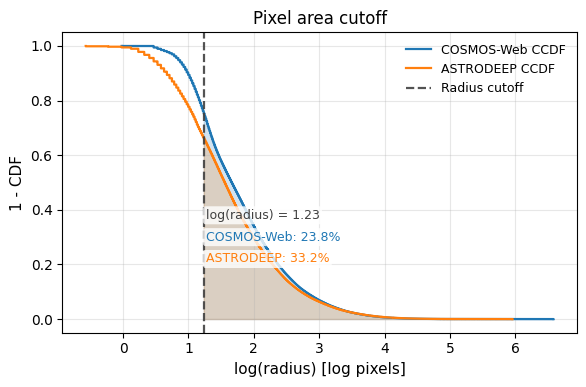

In [45]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9
})

def _log_radius_array(df, col='seg_area'):
    areas = df.loc[df[col] > 0, col].to_numpy()
    if areas.size == 0:
        return (np.array([]), np.array([])), None, None
    radii = np.sqrt(areas / np.pi)  # radius in pixels
    x = np.log(radii)  # log-radius
    x_sorted = np.sort(x)
    n = x_sorted.size
    ccdf = 1.0 - (np.arange(1, n + 1) / n)  # empirical CCDF
    radius_cutoff = MIN_CUTOUT_SIZE / CUTOUT_FACTOR
    x_cutoff = np.log(radius_cutoff)
    percentile_match = (radii <= radius_cutoff).mean()
    return (x_sorted, ccdf), x_cutoff, percentile_match

def plot_ccdf_with_cutoff(df1, df2, col='seg_area',
                          labels=('Dataset A','Dataset B'),
                          colors=('tab:blue','tab:orange'),
                          savepath='ccdf.pdf'):
    (data1, xcut1, pct1) = _log_radius_array(df1, col)
    (data2, xcut2, pct2) = _log_radius_array(df2, col)

    print(f"{labels[0]}: implemented cutoff corresponds to percentile {pct1:.2%}")
    print(f"{labels[1]}: implemented cutoff corresponds to percentile {pct2:.2%}")

    fig, ax = plt.subplots(figsize=(6, 4))

    if data1[0].size:
        ax.step(data1[0], data1[1], where="post", color=colors[0],
                linewidth=1.6, label=f"{labels[0]} CCDF")
        mask = data1[0] >= xcut1
        ax.fill_between(data1[0][mask], data1[1][mask], step="post",
                        color=colors[0], alpha=0.2)

    if data2[0].size:
        ax.step(data2[0], data2[1], where="post", color=colors[1],
                linewidth=1.6, label=f"{labels[1]} CCDF")
        mask = data2[0] >= xcut2
        ax.fill_between(data2[0][mask], data2[1][mask], step="post",
                        color=colors[1], alpha=0.2)

    shared_xcut = next((x for x in (xcut1, xcut2) if x is not None), None)
    if shared_xcut is not None:
        ax.axvline(
            shared_xcut,
            color="0.25",
            linestyle="--",
            alpha=0.9,
            linewidth=1.6,
            label="Radius cutoff",
        )
        ax.text(
            shared_xcut + 0.03,
            0.38,
            f"log(radius) = {shared_xcut:.2f}",
            color="0.25",
            fontsize=9,
            ha="left",
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8),
        )
        ax.text(
            shared_xcut + 0.03,
            0.30,
            f"{labels[0]}: {pct1:.1%}",
            color=colors[0],
            fontsize=9,
            ha="left",
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8),
        )
        ax.text(
            shared_xcut + 0.03,
            0.22,
            f"{labels[1]}: {pct2:.1%}",
            color=colors[1],
            fontsize=9,
            ha="left",
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8),
        )

    ax.set_title("Pixel area cutoff")
    ax.set_xlabel("log(radius) [log pixels]")
    ax.set_ylabel("1 - CDF")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", ncol=1, frameon=False)

    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.tight_layout()
    plt.show()

plot_ccdf_with_cutoff(cosmos_matches_df, astrodeep_matches_df,
                      labels=('COSMOS-Web','ASTRODEEP'))

In [10]:
astrodeep_cutouts_df

,file_path,RA,DEC,CATALOGUE,zphot,flag
0,/media/home/team_workspaces/AnomalyMatch-JWST-...,53.186660,-27.735163,astrodeep,0.104,70
1,/media/home/team_workspaces/AnomalyMatch-JWST-...,53.190294,-27.740110,astrodeep,0.525,300
2,/media/home/team_workspaces/AnomalyMatch-JWST-...,53.180999,-27.732003,astrodeep,0.450,170
3,/media/home/team_workspaces/AnomalyMatch-JWST-...,53.168874,-27.733339,astrodeep,0.025,10200
4,/media/home/team_workspaces/AnomalyMatch-JWST-...,53.190173,-27.735036,astrodeep,0.725,370
...,...,...,...,...,...,...
314444,/media/home/team_workspaces/AnomalyMatch-JWST-...,150.110684,2.345976,astrodeep,2.450,2
314445,/media/home/team_workspaces/AnomalyMatch-JWST-...,150.112358,2.347481,astrodeep,1.675,302
314446,/media/home/team_workspaces/AnomalyMatch-JWST-...,150.117038,2.373263,astrodeep,0.150,1
314447,/media/home/team_workspaces/AnomalyMatch-JWST-...,150.112858,2.353153,astrodeep,8.900,102


In [9]:
cosmos_matches_df.assign(radius = cosmos_matches_df.seg_area.apply(lambda x: 3.5 * np.sqrt(x / np.pi))).query('radius >= 11.39')

,seg_area,RA,DEC,file_path,radius
78115,43.0,149.961345,2.268378,/media/home/data/user/jwst_jw01/jw01727/jw0172...,12.948735
66516,742.0,149.944353,2.273315,/media/home/data/user/jwst_jw01/jw01727/jw0172...,53.789197
27372,83.0,149.936279,2.279093,/media/home/data/user/jwst_jw01/jw01727/jw0172...,17.990041
66519,282.0,149.936419,2.278024,/media/home/data/user/jwst_jw01/jw01727/jw0172...,33.160240
66515,203.0,149.944617,2.273621,/media/home/data/user/jwst_jw01/jw01727/jw0172...,28.134625
...,...,...,...,...,...
398301,293.0,149.911938,2.590286,/media/home/data/user/jwst_jw01/jw01727/jw0172...,33.800795
398357,377.0,149.911626,2.591047,/media/home/data/user/jwst_jw01/jw01727/jw0172...,38.341031
66520,260.0,150.031138,2.246097,/media/home/data/user/jwst_jw01/jw01727/jw0172...,31.840493
157009,43.0,150.296842,2.148913,/media/home/data/user/jwst_jw01/jw01727/jw0172...,12.948735


## Manual cutout for lenses without match in ASTRODEEP / COSMOS

In [243]:
replacements_df = pd.read_csv('replacements.csv')
replacements_df['computed_area'] = np.full(len(replacements_df), None)

149.89981 2.519547
(238, 238)


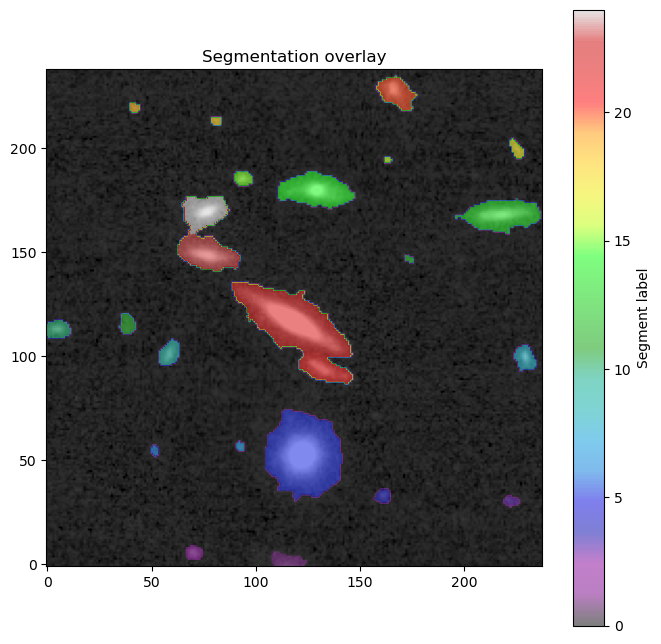

Label <photutils.segmentation.catalog.SourceCatalog>
Length: 1
labels: [22]: area = 1105.0 pix^2


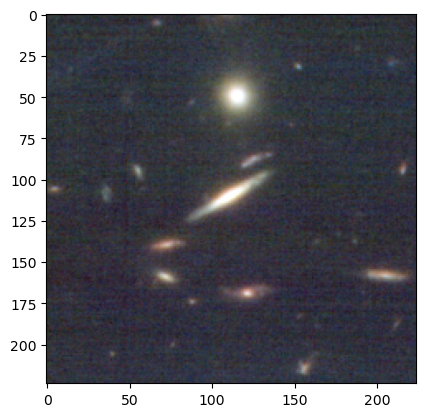

21 Actual cutout None


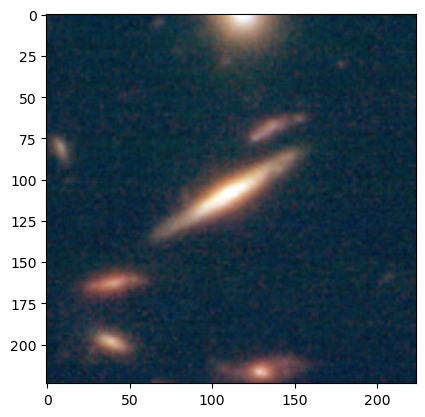

In [245]:
from photutils.background import Background2D, MedianBackground
from astropy.convolution import convolve
from photutils.segmentation import make_2dgaussian_kernel
from photutils.segmentation import detect_sources
from photutils.segmentation import deblend_sources
from photutils.segmentation import SourceCatalog
from astropy.visualization import simple_norm

dir_to_save_imgs = 'temp_manual_cutouts/'

for df_idx, row in replacements_df.iterrows():
    file_path = row['fits_file_path']
    file_flt = [ff for ff in JWST_FILTERS if ff in file_path][0]
    prod_type = file_path.split(file_flt)[0] 
    fits_files = [file_path.replace(file_flt, other_flt) for other_flt in JWST_FILTERS if \
                           os.path.isfile(file_path.replace(file_flt, other_flt))]
    print(row['RA'], row['DEC'])
    all_wcs, all_data = [], []
    for fits_file in fits_files:
        with fits.open(fits_file) as hdul:
            data = hdul['SCI'].data 
            header = hdul['SCI'].header
        all_wcs.append(WCS(header))
        all_data.append(data)
        hdul.close()
        
    ras = [row['RA']] * len(fits_files)
    decs = [row['DEC']] * len(fits_files)
    sizes = [15] * len(fits_files)
    
    cutout = create_list_one_band_cutout(fits_files, all_wcs, all_data, ras, decs, sizes)
    print(cutout['orig_shape'])
    c_data = cutout['object'].data
    bkg_estimator = MedianBackground()
    bkg = Background2D(c_data, (20, 20), filter_size=(3, 3),
                       bkg_estimator=bkg_estimator)
    c_data -= bkg.background
    threshold =  1.5 * bkg.background_rms
    kernel = make_2dgaussian_kernel(4.0, size=5)  # FWHM = 3.0
    convolved_data = convolve(c_data, kernel)
    segment_map = detect_sources(convolved_data, threshold, npixels=10)
    segm_deblend = deblend_sources(convolved_data, segment_map,
                               npixels=10, nlevels=32, contrast=0.001,
                               progress_bar=False)
    
    norm = simple_norm(c_data, 'sqrt', percent=99.)

    plt.figure(figsize=(8, 8))
    plt.imshow(c_data, origin='lower', cmap='Greys_r', norm=norm)
    plt.imshow(segm_deblend.data, origin='lower', cmap='nipy_spectral', alpha=0.5)
    plt.title("Segmentation overlay")
    plt.colorbar(label="Segment label")
    plt.show()
    
    catalog = SourceCatalog(convolved_data, segm_deblend, wcs=cutout['object'].wcs)
    coord = SkyCoord(ra=row['RA']*u.deg, dec=row['DEC']*u.deg)
    x, y = cutout['object'].wcs.world_to_pixel(coord)
    label_at_coord = segm_deblend.data[int(y), int(x)]
    if label_at_coord > 0:
        idx = np.where(catalog.label == label_at_coord)[0][0]
        label = catalog[idx]
        area_pix = catalog.area[idx].value
        replacements_df.iloc[df_idx, replacements_df.columns.get_loc('computed_area')] = area_pix
    else:
        print('No label at coord.')
        
    print(f"Label {label}: area = {area_pix} pix^2")
    f115 = next((v for k, v in cutout.items() if 'f115' in k), None)
    f150 = next((v for k, v in cutout.items() if 'f150' in k), None)
    f277 = next((v for k, v in cutout.items() if 'f277' in k), None)
    f444 = next((v for k, v in cutout.items() if 'f444' in k), None)
    if f115 is not None and f150 is not None and f277 is not None and f444 is not None:
        rgb_mtf = make_mtf_rgb(f115, f150, f277, f444).astype(np.uint8)
        plt.imshow(rgb_mtf)
        plt.show()
        
    print(df_idx, 'Actual cutout', row['computed_area'])
    areas = [area_pix * 16] * len(fits_files)
    
    cutout_2 = create_list_one_band_cutout_w_area(fits_files,
                                             all_wcs, 
                                             all_data, 
                                             ras, 
                                             decs, 
                                             areas=areas)
    
    path_to_save = dir_to_save_imgs + f'MANUAL_' + prod_type.split('/')[-1] + f"{row['RA']}-{row['DEC']}.png"
    prod_type = file_path.split(file_flt)[0]
    replacements_df.iloc[df_idx, replacements_df.columns.get_loc('file_path')] = path_to_save
    f115 = next((v for k, v in cutout_2.items() if 'f115' in k), None)
    f150 = next((v for k, v in cutout_2.items() if 'f150' in k), None)
    f277 = next((v for k, v in cutout_2.items() if 'f277' in k), None)
    f444 = next((v for k, v in cutout_2.items() if 'f444' in k), None)
    if f115 is not None and f150 is not None and f277 is not None and f444 is not None:
        rgb_mtf = make_mtf_rgb(f115, f150, f277, f444).astype(np.uint8)
        plt.imshow(rgb_mtf)
        plt.show()
        cv2.imwrite(path_to_save, cv2.cvtColor(rgb_mtf, cv2.COLOR_RGB2BGR))

## Invalid footprint mask

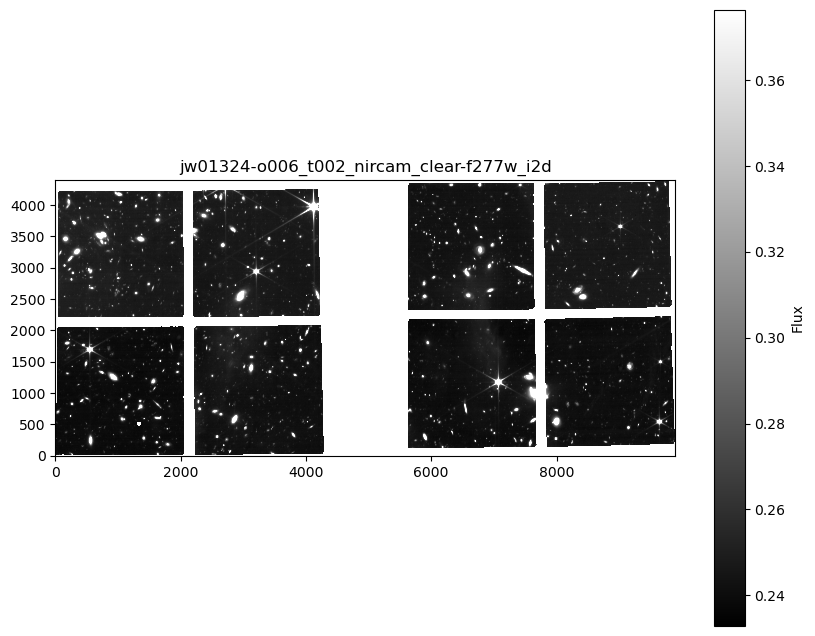

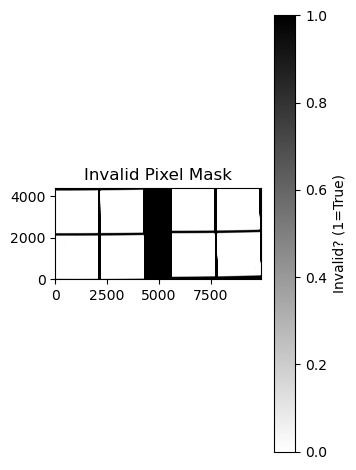

In [ ]:
import matplotlib.pyplot as plt
from astropy.io import fits

def compute_invalid_mask(data):
    mask = (
        ~np.isfinite(data) |      # NaN or inf
        (data == 0)        |      # exactly zero
        (np.var(data[np.isfinite(data)]) < 1e-6)       # no variance
    )
    return mask

with fits.open('/media/home/data/user/jwst_jw01/jw01324/jw01324-o006_t002_nircam_clear-f115w_i2d.fits.gz', memmap=True) as hdul:
    data = hdul['SCI'].data
    mask = compute_invalid_mask(data)

plt.figure(figsize=(10, 8))

# plt.subplot(1, 2, 1)
plt.title('jw01324-o006_t002_nircam_clear-f277w_i2d')
plt.imshow(data, origin="lower", cmap="gray", vmin=np.nanpercentile(data, 1), vmax=np.nanpercentile(data, 99))
plt.colorbar(label="Flux")
plt.savefig('example_jwst.png', dpi=100)
plt.show()
plt.close()
plt.subplot(1, 2, 2)
plt.title("Invalid Pixel Mask")
plt.imshow(mask, origin="lower", cmap="gray_r")  # gray_r = white=valid, black=invalid if inverted
plt.colorbar(label="Invalid? (1=True)")

plt.tight_layout()
plt.show()